# Experiment 1 — Does Autostep separate useful from useless connections?

Learning connectivity online means judging connections by their step-sizes, so Autostep has to hold
useless connections' step-sizes down. Test problem: **stationary 2-task multi-GEOFF**, learned by a
masked two-layer MLP with a block-sparse base structure — each hidden unit wired only to its own
task's inputs and outputs, which makes every cross-task connection useless by construction.

* **1a** — train from scratch with useless connections present, with and without L1.
* **1b** — train the clean structure, then add bad connections mid-training.

Autostep is derived for the linear case, and 1a compares two ways of extending it to a network:
**Variant A** normalizes with squared prediction gradients, **Variant B** with the squared value of
each weight's source unit. 1b uses Variant B only.

In [15]:
import logging
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import (
    BIAS, USEFUL, USELESS, MaskedTwoLayerMLP, add_random_cross_task_connections,
    added_connection_labels, block_sparse_masks, connection_labels, contaminate_masks, gather_at,
    halves_group_ids, masked_quantiles, penalty_masks, reset_idbd_state_at, slot_ids,
    subsample_indices,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

# Variant A knowingly applies Autostep across two layers, which is what `optax_idbd` warns about.
logging.getLogger('phd.jax_core.optimizers.idbd').setLevel(logging.ERROR)

In [16]:
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')     # run caches
os.makedirs(DATA_DIR, exist_ok=True)

# --- Problem: stationary 2-task multi-GEOFF, task defaults ---
N_TASKS = 2
N_FEATURES_PER_TASK = 2
N_OUTPUTS_PER_TASK = 1
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
NOISE_STD = 1.0
PERTURB_PERIOD = None            # None = stationary, no readout permutations

# --- Learner ---
N_HIDDEN = 4
ACTIVATION = 'leaky_relu'
INIT_LR = 1e-6                   # every connection starts here, never swept
META_LR = 0.02                   # one global value: best of 1e-3..2e-2, and no seed diverges
L1_COEFF = 0.01                  # subgradient L1, used in the second half of 1a
USE_BIAS = True                  # a constant-1 input appended to each layer, biases excluded from L1
VERSIONS = {'Variant A': 'prediction_grads', 'Variant B': 'squared_inputs'}

# The static step-size baseline every figure below shows first: no step-size adaptation at all, so
# only |w| can separate the two groups. What has to stay bounded is the effective step-size
# `SGD_LR / (1 - SGD_MOMENTUM)`; at 0.02 no seed diverges, while 0.1 (lr 0.01 with momentum 0.9)
# diverges on 6/30. The cache name carries both values, so re-tuning them re-runs the baseline.
SGD_VERSION = 'sgd'              # `make_learner`'s sentinel, not an `optax_idbd` version
SGD_LR = 0.002
SGD_MOMENTUM = 0.9
SGD_LABEL = f'SGD + momentum (lr {SGD_LR:g}, m {SGD_MOMENTUM:g})'
SGD_TAG = f'sgd_lr{SGD_LR:g}_m{SGD_MOMENTUM:g}'.replace('.', 'p')

CACHE_PREFIX = 'exp1_stationary' + ('_bias' if USE_BIAS else '')

# --- Training and recording ---
NUM_STEPS = 1_000_000            # 1a
N_PRETRAIN_STEPS = 1_000_000     # 1b, before the connections are added
N_POST_STEPS = 2_000_000         # 1b, after
N_SEEDS = 30                     # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 250                # connectivity snapshots per phase
N_TRACES = 30                    # individual connections followed per layer per group
BASE_SEED = 0

LAYERS = ('w1', 'w2')
LAYER_NAMES = ('input layer (hidden $\\leftarrow$ inputs)',
               'output layer (outputs $\\leftarrow$ hidden)')
GROUPS = (USEFUL, USELESS)       # biases are trained but sit outside this comparison
GROUP_COLORS = ('#3b6fb0', '#c0392b')   # blue = useful / original, red = useless / added
QUANTILES = (0.1, 0.5, 0.9)
MEDIAN_IDX = QUANTILES.index(0.5)
SHOW_DISTRIBUTIONS = False       # also draw the per-group quantile bands in 1a

# An optimal predictor sits at per-output MSE = noise_std^2, the mean predictor 1 above it.
IRREDUCIBLE_MSE = NOISE_STD ** 2
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0

INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

## Connectivity

Three structures from one block-sparse base: the clean base (1b before the injection), 1a's
contaminated version (half of the hidden units also fully connected to the other task's outputs,
half to its inputs), and 1b's injected version (1–10 incoming and 1–3 outgoing random cross-task
connections per hidden unit).

With `USE_BIAS`, each layer's input gets a constant 1 appended and every hidden and output unit is
connected to it — a bias as an ordinary weight rather than a separate parameter array, which is
what Autostep needs (its per-output-unit normalizer is a sum over a weight matrix's last axis, so
the bias has to sit in that matrix). Bias weights belong to no task, so they are labelled
separately and excluded from the useful/useless statistics below.

In [17]:
base_masks, hidden_task_ids = block_sparse_masks(
    N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, N_HIDDEN, bias=USE_BIAS)

# 1a: contaminate the base structure; every added connection crosses tasks and so is useless.
masks_1a = contaminate_masks(base_masks, hidden_task_ids, halves_group_ids(hidden_task_ids),
                             INPUT_TASK_IDS, OUTPUT_TASK_IDS)
labels_1a = connection_labels(masks_1a, hidden_task_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS)

# 1b: the same base structure plus random cross-task connections, activated mid-training. Here the
# split of interest is original-vs-added rather than same-task-vs-cross-task (they coincide, since
# the pre-existing structure is pure block-sparse).
masks_1b, added_1b = add_random_cross_task_connections(
    base_masks, hidden_task_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS, jax.random.PRNGKey(BASE_SEED))
labels_1b = added_connection_labels(masks_1b, added_1b, bias=USE_BIAS)

for name, labels in (('1a', labels_1a), ('1b', labels_1b)):
    for layer in LAYERS:
        lab = labels[layer]
        print(f'{name} {layer}:  useful {int((lab == USEFUL).sum()):4d}   '
              f'useless {int((lab == USELESS).sum()):4d}   '
              f'bias {int((lab == BIAS).sum()):4d}')

added_in = added_1b['w1'].sum(1)                      # per hidden unit; the bias column adds none
added_out = added_1b['w2'][:, :N_HIDDEN].sum(0)       # drop the bias column, it is not a unit
print(f'1b added per hidden unit: incoming {int(added_in.min())}-{int(added_in.max())}, '
      f'outgoing {int(added_out.min())}-{int(added_out.max())}')

1a w1:  useful    8   useless    4   bias    4
1a w2:  useful    4   useless    2   bias    2
1b w1:  useful    8   useless    7   bias    4
1b w2:  useful    4   useless    4   bias    2
1b added per hidden unit: incoming 1-2, outgoing 1-1


In [18]:
masks_1a

{'w1': Array([[1., 1., 0., 0., 1.],
        [1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], dtype=float32),
 'w2': Array([[1., 1., 1., 0., 1.],
        [1., 0., 1., 1., 1.]], dtype=float32)}

## Learner

A masked two-layer MLP trained online, either with Autostep or — as the baseline every comparison
below starts from — with plain SGD + momentum at a single static step-size. Connectivity is a 0/1
mask multiplied into the weights at forward time, so any topology is expressible and a connection
can be toggled with a single `.at[]` write. Biases are the last column of each weight matrix and are
trained like every other weight; the L1 penalty skips them, since shrinking a bias fights the
target's nonzero mean instead of pruning structure.

The SGD baseline has no step-size to separate the two groups with — every connection keeps `SGD_LR`
forever — so it says what the weights alone do, and how much loss the adaptation costs or buys. It
is reported through the same `step_sizes` interface as Autostep, which is why its (flat) step-size
still appears in the figures.

In [19]:
class AutostepMLP(eqx.Module):
    """Masked two-layer MLP trained online with Autostep, optionally with subgradient L1."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    version: str = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    l1_masks: dict                # active connections the L1 penalty applies to, biases excluded
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState

    @classmethod
    def init(cls, masks, version, key, l1=0.0):
        optimizer = optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True, version=version)
        model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, bias=USE_BIAS, key=key)
        return cls(optimizer=optimizer, version=version, l1=l1,
                   l1_masks=penalty_masks(model.masks, bias=USE_BIAS), model=model,
                   opt_state=optimizer.init(model.weights))

    @property
    def step_sizes(self):
        """The adapted per-connection step-sizes, which is what `snapshot` records."""
        return {k: jnp.exp(self.opt_state.beta[k]) for k in LAYERS}

    def step(self, x, y):
        """One online update. Returns the new learner and the squared error summed over outputs."""
        def loss_fn(weights):
            out, param_inputs = tree_replace(self.model, weights=weights)(x)
            return jnp.sum((out - y) ** 2), param_inputs

        (loss, param_inputs), grads = jax.value_and_grad(loss_fn, has_aux=True)(self.model.weights)

        if self.l1 > 0.0:
            # L1 goes into the gradient Autostep consumes, so it shapes step-size adaptation too.
            # `loss` stays pure squared error, so the MSE curves stay comparable across runs.
            grads = {k: g + self.l1 * jnp.sign(self.model.weights[k]) * self.l1_masks[k]
                     for k, g in grads.items()}

        if self.version == 'prediction_grads':
            # Variant A: no hessian term, normalize by the squared prediction gradients.
            pred_grads = jax.grad(
                lambda w: jnp.sum(tree_replace(self.model, weights=w)(x)[0]))(self.model.weights)
            update_input = (grads, pred_grads)
        else:
            # Variant B: each layer is its own linear problem, so normalize by the squared value of
            # each weight's source unit — already returned by the forward pass. With a bias that
            # source value is the constant 1, so its curvature term is 1 and its step-size enters
            # the same per-output-unit normalizer as the rest of the layer.
            update_input = (grads, None, param_inputs)

        updates, opt_state = self.optimizer.update(update_input, self.opt_state, self.model.weights)
        weights = {k: self.model.weights[k] + updates[k] for k in updates}
        return tree_replace(self, model=tree_replace(self.model, weights=weights),
                            opt_state=opt_state), loss


class SGDMLP(eqx.Module):
    """The same network trained with plain SGD + momentum: one static step-size for everything.

    Interchangeable with `AutostepMLP` — same `step` and `step_sizes` — so every run, figure and
    table below takes either. Masked-out connections stay inert here too: the mask zeroes their loss
    gradient, so their momentum trace never leaves 0 and their weight never leaves 0.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    lr: float = eqx.field(static=True)
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState

    @classmethod
    def init(cls, masks, key, lr=SGD_LR, momentum=SGD_MOMENTUM):
        optimizer = optax.sgd(lr, momentum=momentum)
        model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, bias=USE_BIAS, key=key)
        return cls(optimizer=optimizer, lr=lr, model=model,
                   opt_state=optimizer.init(model.weights))

    @property
    def step_sizes(self):
        """Static by construction, reported anyway so the figures stay comparable."""
        return {k: jnp.full_like(self.model.weights[k], self.lr) for k in LAYERS}

    def step(self, x, y):
        """One online update. Returns the new learner and the squared error summed over outputs."""
        def loss_fn(weights):
            out, _ = tree_replace(self.model, weights=weights)(x)
            return jnp.sum((out - y) ** 2)

        loss, grads = jax.value_and_grad(loss_fn)(self.model.weights)
        updates, opt_state = self.optimizer.update(grads, self.opt_state, self.model.weights)
        weights = {k: self.model.weights[k] + updates[k] for k in updates}
        return tree_replace(self, model=tree_replace(self.model, weights=weights),
                            opt_state=opt_state), loss


def make_learner(masks, version, key, l1=0.0):
    """`version=SGD_VERSION` builds the static step-size baseline, anything else an Autostep variant."""
    if version == SGD_VERSION:
        assert l1 == 0.0, "The SGD baseline is run without L1!"
        return SGDMLP.init(masks, key)
    return AutostepMLP.init(masks, version, key, l1=l1)

## Training and recording

A nested scan: an inner scan over steps emitting the loss, an outer scan emitting one connectivity
snapshot per block (per-group quantiles plus up to `N_TRACES` fixed individual connections — groups
smaller than that are padded with NaN, so their traces simply go unplotted). Runs are cached to
`data/`, so re-running the notebook recomputes nothing.

In [20]:
def snapshot(learner, labels, trace_idxs):
    """Per-group quantiles and the traced connections' values, for step-sizes and |w|."""
    values = {'alpha': learner.step_sizes,
              'absw': {k: jnp.abs(learner.model.weights[k]) for k in LAYERS}}
    stack = lambda fn: jnp.stack([jnp.stack([fn(l, g) for g in GROUPS]) for l in LAYERS])
    return {
        **{f'{n}_q': stack(lambda l, g, _v=v: masked_quantiles(_v[l], labels[l], g, QUANTILES))
           for n, v in values.items()},
        **{f'{n}_tr': stack(lambda l, g, _v=v: gather_at(_v[l], trace_idxs[l][g]))
           for n, v in values.items()},
    }


def train(learner, task, labels, trace_idxs, n_steps):
    """`n_steps` of online training, returning the per-step loss and `N_SNAPSHOTS` snapshots."""
    def one_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(1)          # online: one sample per step
        learner, loss = learner.step(x[0], y[0])
        return (learner, task), loss

    def block(carry, _):
        carry, losses = jax.lax.scan(one_step, carry, length=n_steps // N_SNAPSHOTS)
        return carry, (losses, snapshot(carry[0], labels, trace_idxs))   # end-of-block snapshot

    carry, (losses, snaps) = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return carry, losses.reshape(-1), snaps


def trace_idxs_for(labels):
    """Fix which individual connections are followed, once, outside of `jit`."""
    return {l: {g: subsample_indices(labels[l], g, N_TRACES, seed=BASE_SEED) for g in GROUPS}
            for l in LAYERS}


def tasks_for(n_seeds):
    """One independent teacher per seed, stacked for `vmap` (the task takes an int seed, not a key)."""
    return stack_pytrees([
        MultiGEOFFTask(N_TASKS, perturb_period=PERTURB_PERIOD,
                       n_features_per_task=N_FEATURES_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD,
                       seed=BASE_SEED + s)
        for s in range(n_seeds)])


def snapshot_steps(n_steps, offset=0):
    """Step index of each snapshot (the end of its block)."""
    return offset + np.arange(1, N_SNAPSHOTS + 1) * (n_steps // N_SNAPSHOTS)


def curve(losses, n_points=250):
    """Per-output MSE binned to `n_points`: (steps, mean over seeds, std over seeds)."""
    mse = np.asarray(losses, dtype=np.float32) / N_OUTPUTS
    n_seeds, width = mse.shape[0], mse.shape[1] // n_points
    binned = mse[:, :n_points * width].reshape(n_seeds, n_points, width).mean(2)
    return np.arange(1, n_points + 1) * width, binned.mean(0), binned.std(0)


def cached(name, fn):
    """Run `fn` once, caching every array it returns in `data/<name>.npz`."""
    path = os.path.join(DATA_DIR, f'{CACHE_PREFIX}_{name}.npz')
    if not os.path.exists(path):
        print(f'running {name} ...')
        np.savez_compressed(path, **{k: np.asarray(v) for k, v in fn().items()})
    with np.load(path) as z:
        return {k: z[k] for k in z.files}

In [21]:
def plot_curves(runs, title, vline=None):
    """Per-output MSE per run, mean +- 2 standard errors over seeds."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        sem = res['curve_std'] / np.sqrt(N_SEEDS)
        plt.plot(res['curve_steps'], res['curve_mse'], color=color, label=label)
        plt.fill_between(res['curve_steps'], res['curve_mse'] - 2 * sem,
                         res['curve_mse'] + 2 * sem, color=color, alpha=0.2)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    if vline is not None:
        plt.axvline(vline, c='k', lw=1.2, alpha=0.6)
    plt.xlabel('step')
    plt.ylabel('per-output MSE')
    plt.title(title)
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def alpha_ref_for(label):
    """Where a run's step-size adaptation started, or None for SGD, which does not adapt."""
    return None if label == SGD_LABEL else INIT_LR


def plot_run(res, group_names, title, bands=False, from_step=0, vline=None, alpha_ref=INIT_LR):
    """One figure per run: step-size on top, |w| below; input layer left, output layer right.

    `bands=False` draws the `N_TRACES` individual connections of the first seed; `bands=True` draws
    the group median and the 10-90% band, averaged over seeds. `alpha_ref` is the reference line
    marking where step-size adaptation started (see `alpha_ref_for`).
    """
    sel = res['snap_steps'] >= from_step
    steps = res['snap_steps'][sel]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    for row, (key, ylabel, log_scale) in enumerate([('alpha', 'step-size $\\alpha$', True),
                                                    ('absw', '$|w|$', False)]):
        for col, layer_name in enumerate(LAYER_NAMES):
            ax = axes[row, col]
            for group, (name, color) in enumerate(zip(group_names, GROUP_COLORS)):
                if bands:
                    q = np.nanmean(res[f'{key}_q'][:, sel, col, group], axis=0)
                    ax.plot(steps, q[:, MEDIAN_IDX], color=color, lw=1.8, label=name)
                    ax.fill_between(steps, q[:, 0], q[:, -1], color=color, alpha=0.2, lw=0,
                                    label=f'{QUANTILES[0]:.0%}–{QUANTILES[-1]:.0%}')
                else:
                    ax.plot(steps, res[f'{key}_tr'][0, sel, col, group], color=color, lw=0.7,
                            alpha=0.5)
                    ax.plot([], [], color=color, lw=1.5, label=name)     # legend proxy
            if log_scale:
                ax.set_yscale('log')
                if alpha_ref is not None:
                    ax.axhline(alpha_ref, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            if vline is not None:
                ax.axvline(vline, c='k', lw=1.2, alpha=0.6)
            ax.grid(alpha=0.35, which='both')
            ax.set_title(layer_name if row == 0 else '')
            ax.set_xlabel('step' if row == 1 else '')
            ax.set_ylabel(ylabel if col == 0 else '')
    axes[0, 1].legend(fontsize=8)
    fig.suptitle(title + ('  —  distribution over connections' if bands
                          else f'  —  {N_TRACES} sampled connections per group'))
    fig.tight_layout()
    plt.show()


def separation_table(runs, group_names):
    """Median step-size and |w| per group at the final snapshot. A ratio > 1 means separation."""
    good, bad = group_names
    rows = []
    for label, res in runs.items():
        for li, layer in enumerate(LAYERS):
            med = lambda key, g, _li=li: float(
                np.nanmean(res[f'{key}_q'][:, -1, _li, g, MEDIAN_IDX]))
            rows.append({
                'run': label, 'layer': layer,
                f'alpha {good}': med('alpha', 0), f'alpha {bad}': med('alpha', 1),
                'alpha ratio': med('alpha', 0) / med('alpha', 1),
                f'|w| {good}': med('absw', 0), f'|w| {bad}': med('absw', 1),
                '|w| ratio': med('absw', 0) / med('absw', 1),
            })
    return pd.DataFrame(rows)

## 1a — useless connections present from the start

Train the contaminated structure from scratch, under both variants, with and without L1, against the
static step-size baseline. Useful connections' step-sizes should climb off 1e-6 while useless ones
stay near it — the baseline shows what the same network does when nothing separates them but the
weights themselves.

In [22]:
def run_1a(version, l1, n_steps=NUM_STEPS, n_seeds=N_SEEDS):
    """Train the mixed-relevance network from scratch; the structure never changes."""
    trace_idxs = trace_idxs_for(labels_1a)
    tasks = tasks_for(n_seeds)

    def one_seed(key, task):
        learner = make_learner(masks_1a, version, key, l1=l1)
        _, losses, snaps = train(learner, task, labels_1a, trace_idxs, n_steps)
        return losses, snaps

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    losses, snaps = jax.jit(jax.vmap(one_seed))(keys, tasks)

    steps, mse, std = curve(losses)
    return {'curve_steps': steps, 'curve_mse': mse, 'curve_std': std,
            'snap_steps': snapshot_steps(n_steps), **snaps}


GROUP_NAMES_1A = ('useful (same task)', 'useless (cross task)')
RUNS_1A = {SGD_LABEL: cached(f'1a_{SGD_TAG}', lambda: run_1a(SGD_VERSION, 0.0))}
for variant, version in VERSIONS.items():
    for suffix, l1 in (('', 0.0), (f' + L1 {L1_COEFF:g}', L1_COEFF)):
        RUNS_1A[variant + suffix] = cached(
            f'1a_{version}' + ('_l1' if l1 else ''), lambda v=version, c=l1: run_1a(v, c))

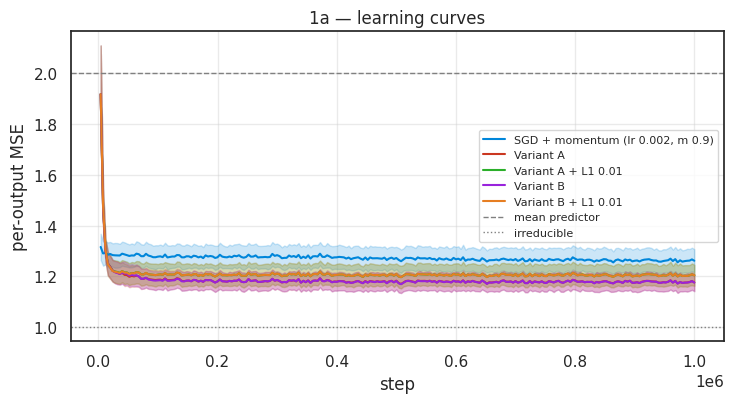

In [23]:
plot_curves(RUNS_1A, '1a — learning curves')

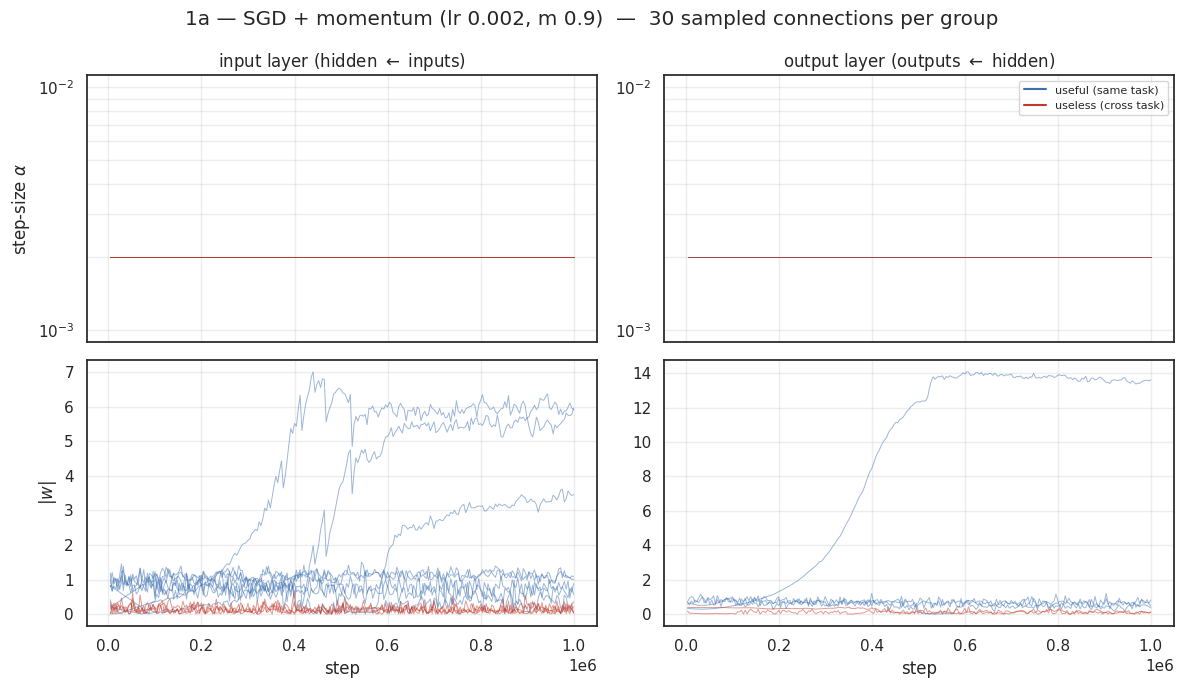

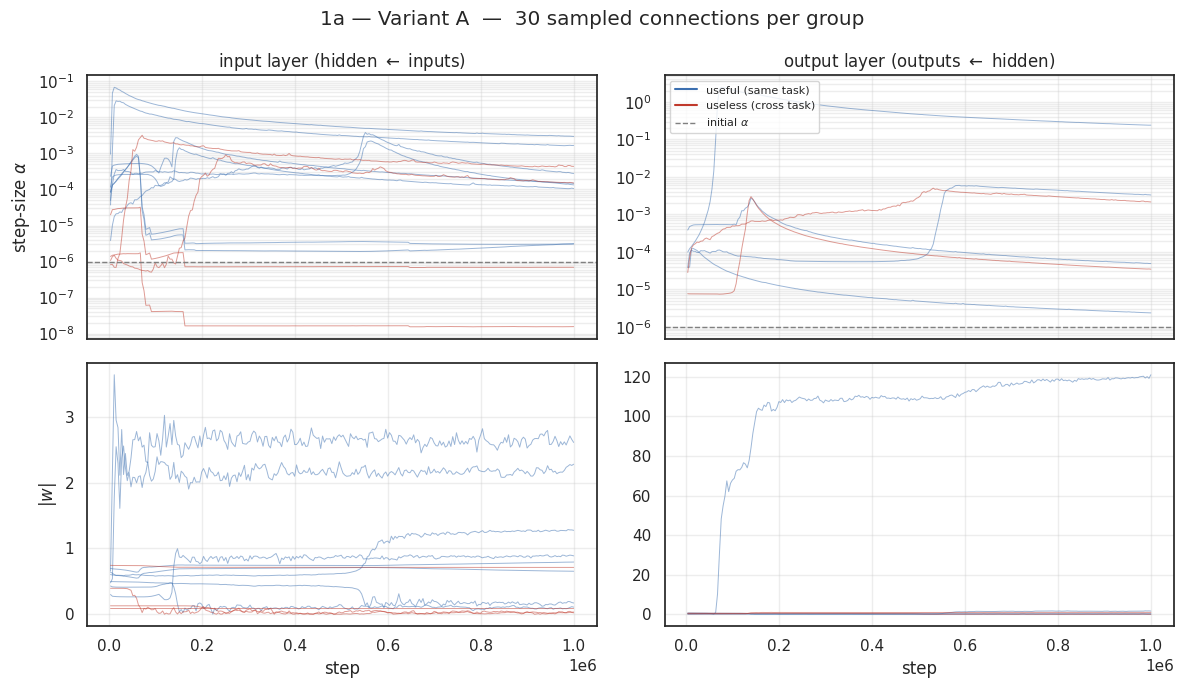

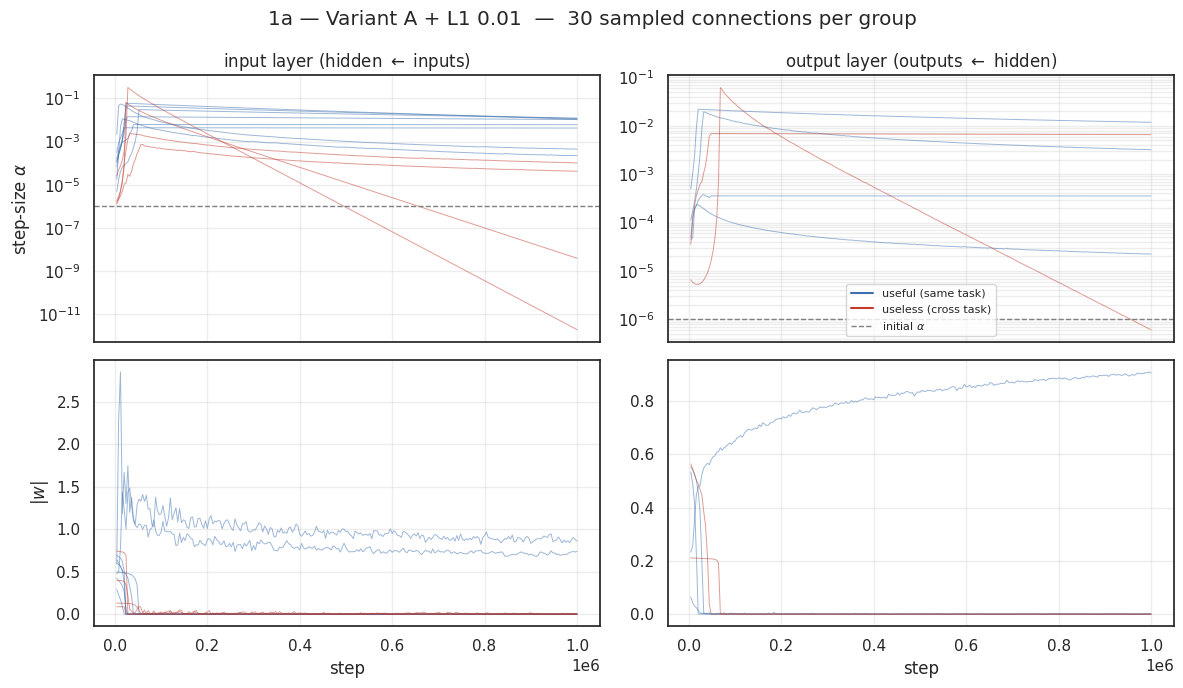

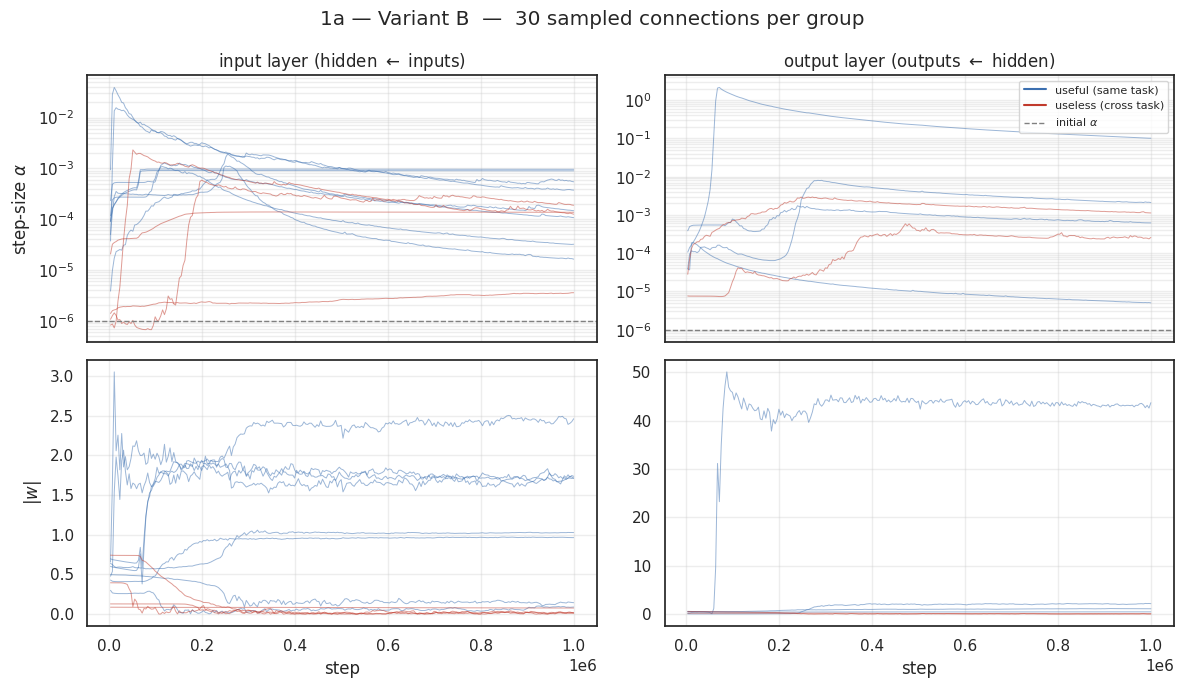

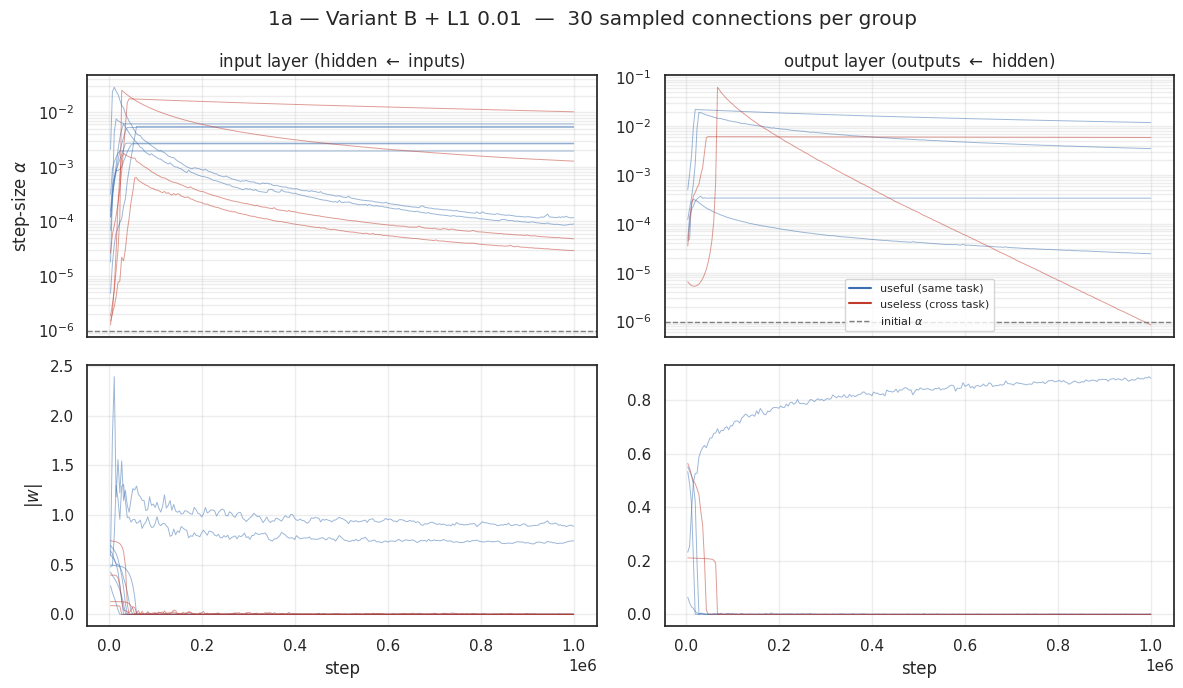

In [24]:
for label, res in RUNS_1A.items():
    plot_run(res, GROUP_NAMES_1A, f'1a — {label}', alpha_ref=alpha_ref_for(label))
    if SHOW_DISTRIBUTIONS:
        plot_run(res, GROUP_NAMES_1A, f'1a — {label}', bands=True, alpha_ref=alpha_ref_for(label))

In [25]:
print(separation_table(RUNS_1A, ('useful', 'useless'))
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                             run layer  alpha useful  alpha useless  alpha ratio  |w| useful  |w| useless  |w| ratio
SGD + momentum (lr 0.002, m 0.9)    w1         0.002          0.002            1       1.278       0.1634      7.821
SGD + momentum (lr 0.002, m 0.9)    w2         0.002          0.002            1       1.792       0.1521      11.78
                       Variant A    w1     0.0006757       0.000657        1.028      0.8667      0.06333      13.69
                       Variant A    w2     0.0002573      0.0005454       0.4718      0.7575       0.1338      5.661
             Variant A + L1 0.01    w1      0.001028       0.002066       0.4975      0.3532     0.002698      130.9
             Variant A + L1 0.01    w2     0.0008629       0.002128       0.4055      0.8112     0.002332      347.8
                       Variant B    w1     0.0004611      0.0005048       0.9133      0.8345       0.0694      12.02
                       Variant B    w2     0.0003068      0.0005

## 1b — bad connections added mid-training

Train the clean block-sparse structure for 1M steps, then give every hidden unit cross-task
connections (weight 0, step-size 1e-6) and train 2M more. The added connections are bad but not
strictly useless — each affected unit now reads *and* feeds the other task — so their weights have
some incentive to move off zero. The best solution still holds them all at 0. Variant B is run with
and without L1, against the same static step-size baseline, which starts the added connections at
`SGD_LR` rather than at 1e-6 and so has nothing holding them down.

In [26]:
def run_1b(version, l1=0.0, n_pretrain=N_PRETRAIN_STEPS, n_post=N_POST_STEPS, n_seeds=N_SEEDS):
    """Pre-train the clean block-sparse network, then activate the cross-task connections.

    The pre-training phase is recorded with the *post*-injection labels, so the figures show the
    flat 1e-6 baseline of the connections that do not exist yet.
    """
    trace_idxs = trace_idxs_for(labels_1b)
    tasks = tasks_for(n_seeds)

    def one_seed(key, task):
        learner = make_learner(base_masks, version, key, l1=l1)
        (learner, task), pre_losses, pre_snaps = train(
            learner, task, labels_1b, trace_idxs, n_pretrain)

        # Activate the new connections: mask on, weight 0, optimizer state back to its initial
        # value. Only the mask flip does anything today — a masked connection is inert, so its
        # weight and state never moved (asserted below) — but this states the intended initial
        # condition. SGD's momentum trace is already 0 at those positions, so it needs no reset.
        model = tree_replace(learner.model, masks=masks_1b,
                             weights={k: learner.model.weights[k] * base_masks[k] for k in LAYERS})
        learner = tree_replace(learner, model=model)
        if version != SGD_VERSION:
            # `l1_masks` was built from the pre-injection structure, so it has to be rebuilt here:
            # otherwise the added connections are the only ones the penalty never sees.
            learner = tree_replace(
                learner, l1_masks=penalty_masks(masks_1b, bias=USE_BIAS),
                opt_state=reset_idbd_state_at(learner.opt_state, added_1b))

        _, losses, snaps = train(learner, task, labels_1b, trace_idxs, n_post)
        return pre_losses, pre_snaps, losses, snaps

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    pre_losses, pre_snaps, losses, snaps = jax.jit(jax.vmap(one_seed))(keys, tasks)

    # 1b only measures a mid-training change if the added connections were untouched before it.
    assert np.allclose(np.asarray(pre_snaps['absw_q'])[..., USELESS, :], 0.0), \
        "Added connections moved before they were activated!"
    if version != SGD_VERSION:
        assert np.allclose(np.asarray(pre_snaps['alpha_q'])[..., USELESS, :], INIT_LR), \
            "Added connections' step-sizes moved before they were activated!"

    # Both phases are recorded end to end, so every figure below can show the whole run.
    pre_steps, pre_mse, pre_std = curve(pre_losses)
    steps, mse, std = curve(losses)
    return {'curve_steps': np.concatenate([pre_steps, steps + n_pretrain]),
            'curve_mse': np.concatenate([pre_mse, mse]),
            'curve_std': np.concatenate([pre_std, std]),
            'snap_steps': np.concatenate([snapshot_steps(n_pretrain),
                                          snapshot_steps(n_post, offset=n_pretrain)]),
            **{k: np.concatenate([pre_snaps[k], v], axis=1) for k, v in snaps.items()}}


GROUP_NAMES_1B = ('original (block-sparse)', 'added (cross task)')
RUNS_1B = {SGD_LABEL: cached(f'1b_{SGD_TAG}', lambda: run_1b(SGD_VERSION))}
for suffix, l1 in (('', 0.0), (f' + L1 {L1_COEFF:g}', L1_COEFF)):
    RUNS_1B['Variant B' + suffix] = cached(
        f"1b_{VERSIONS['Variant B']}" + ('_l1' if l1 else ''),
        lambda c=l1: run_1b(VERSIONS['Variant B'], l1=c))

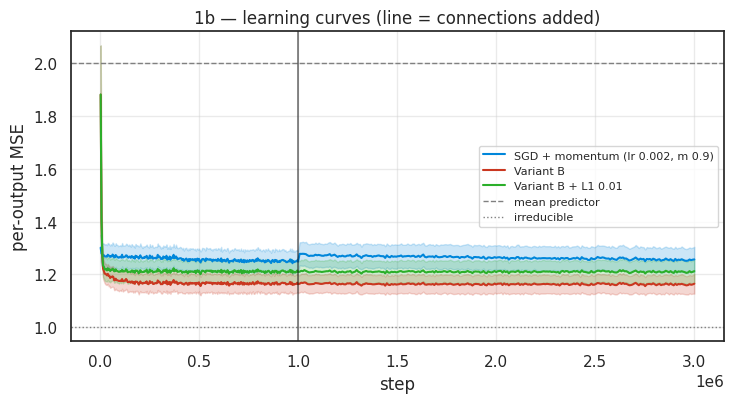

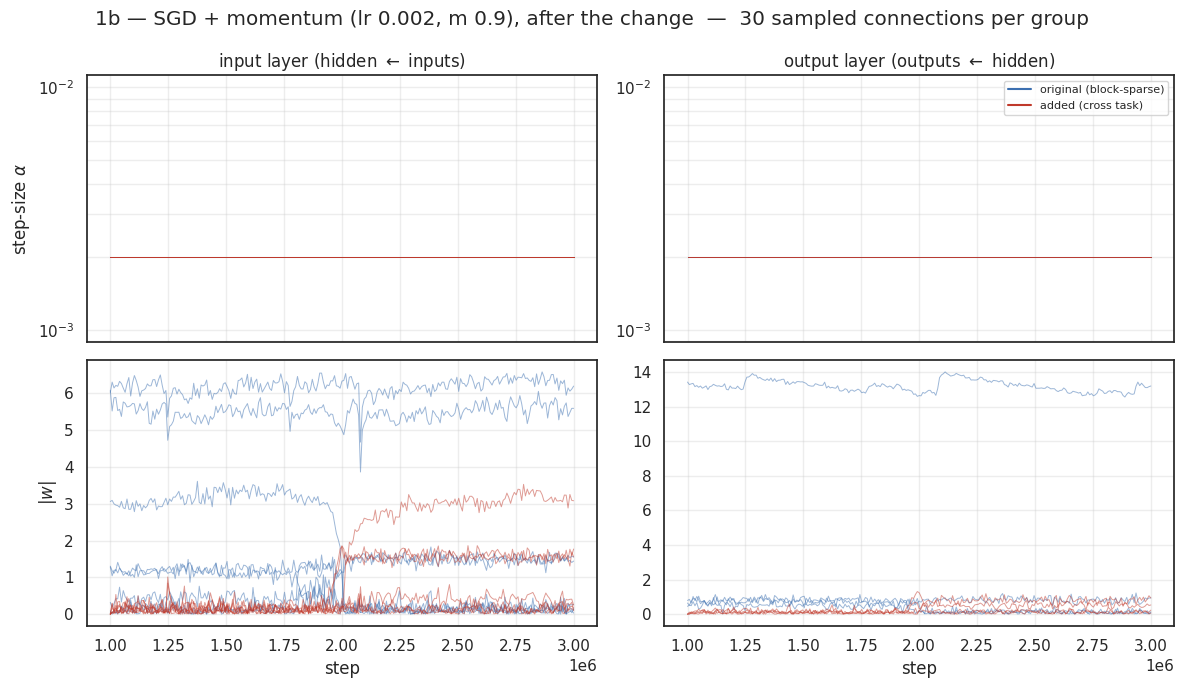

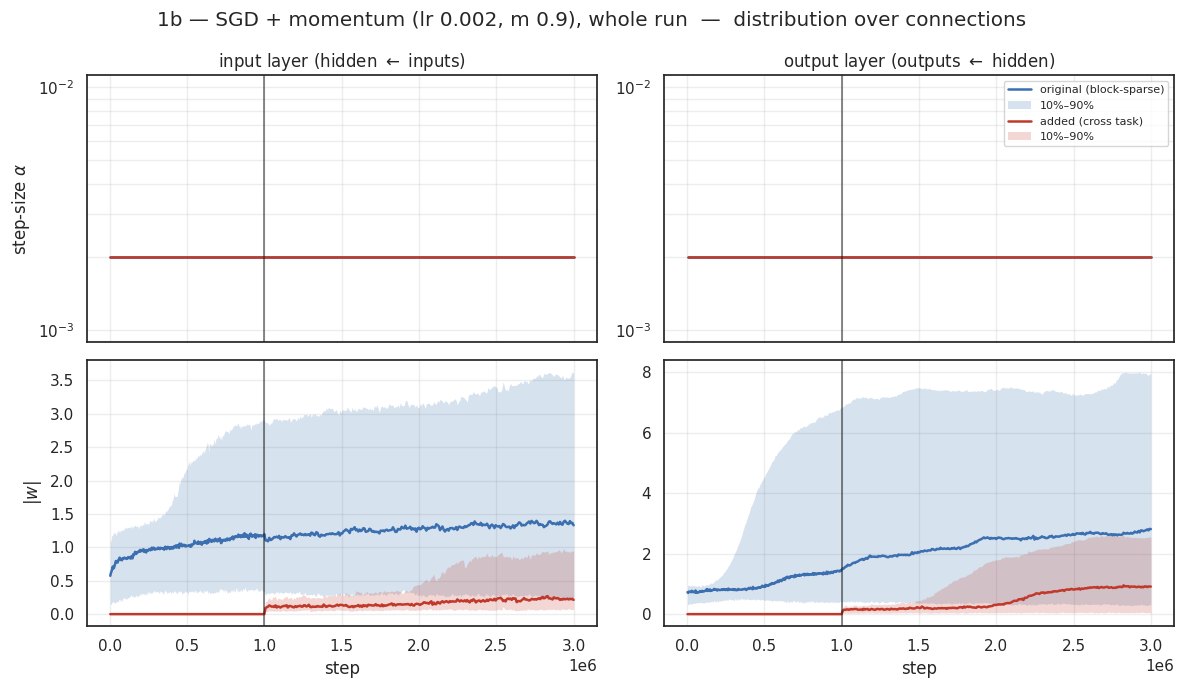

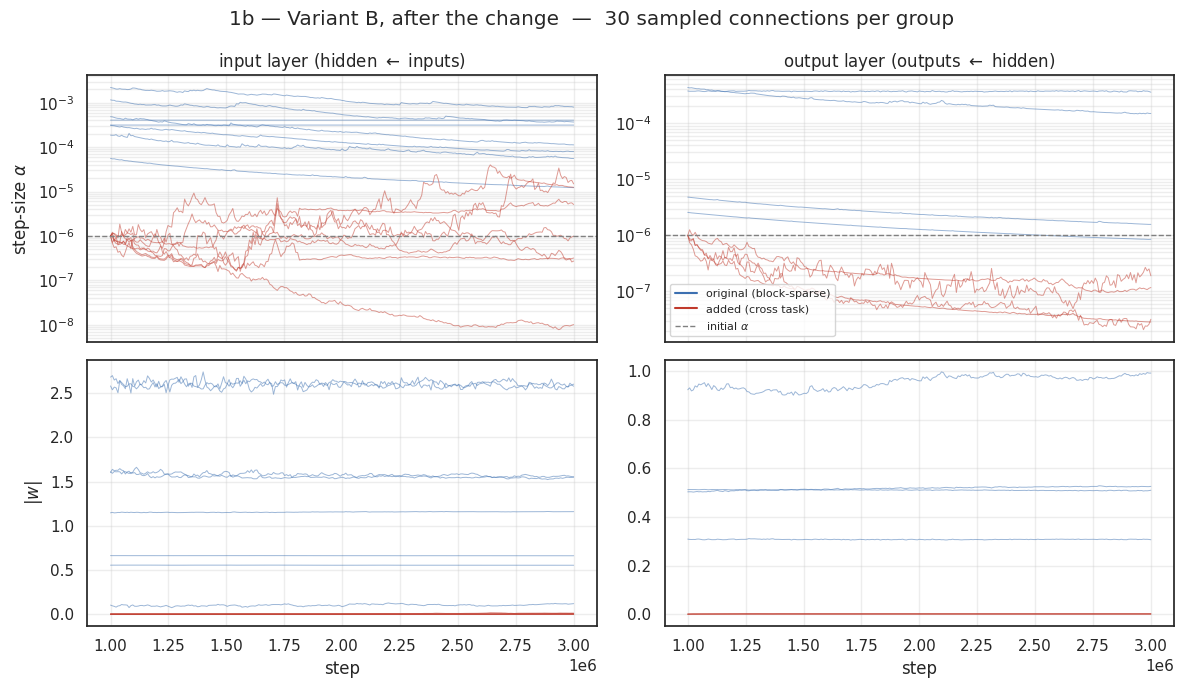

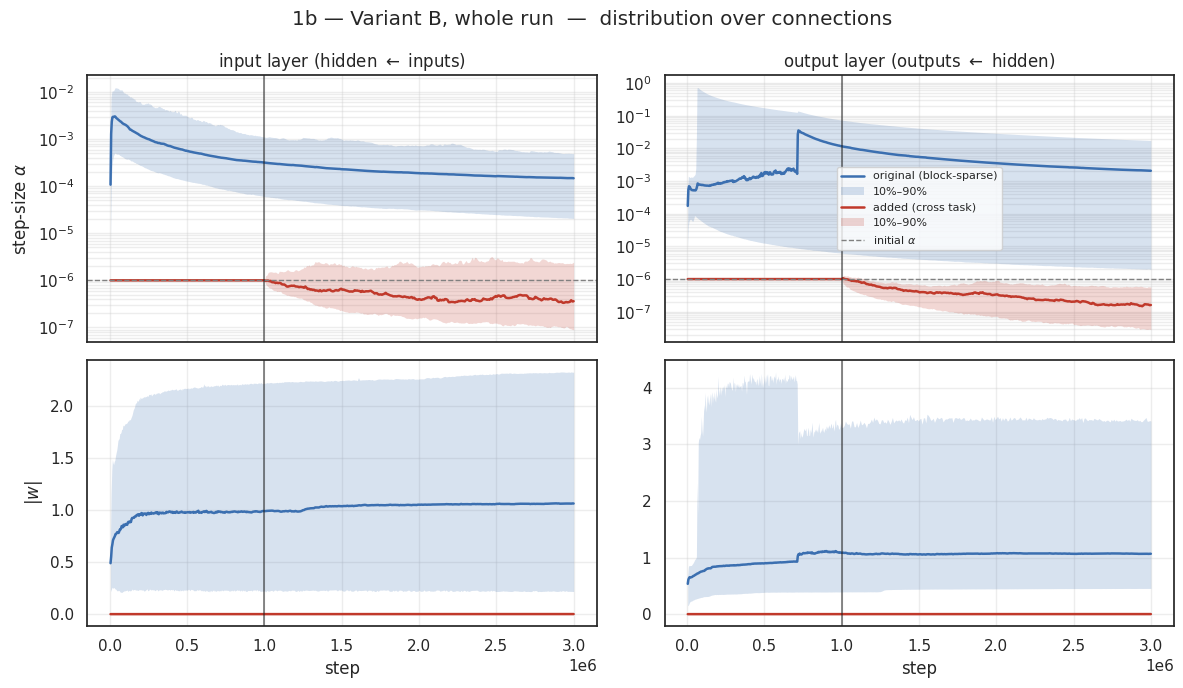

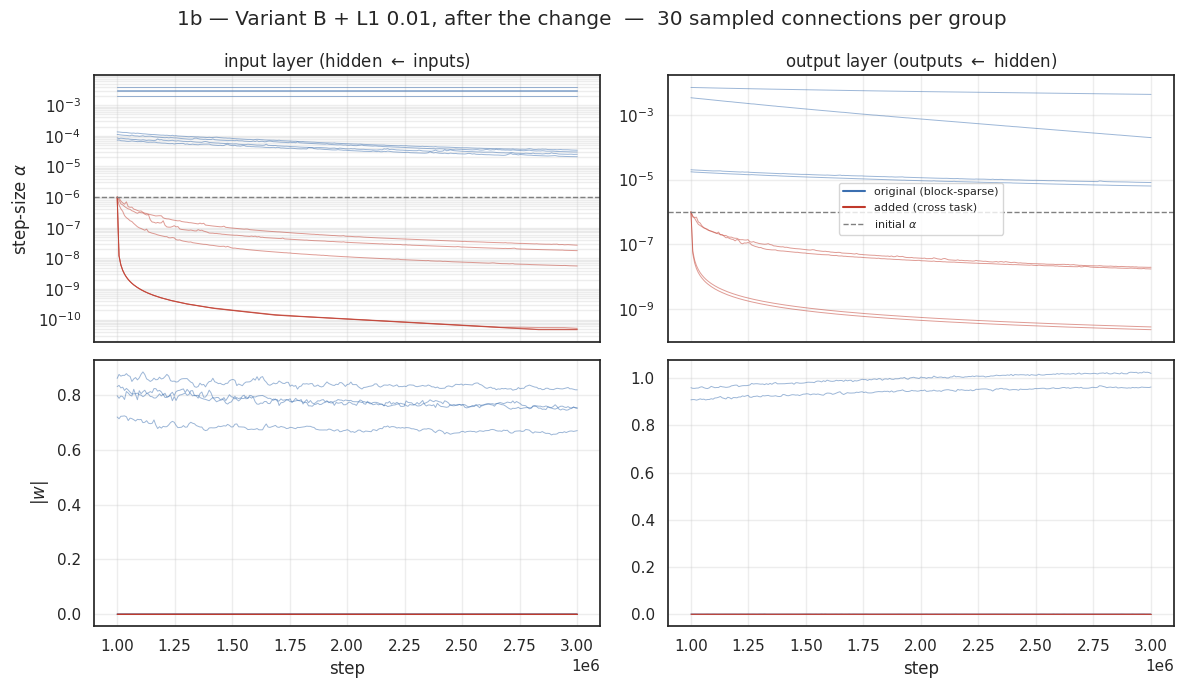

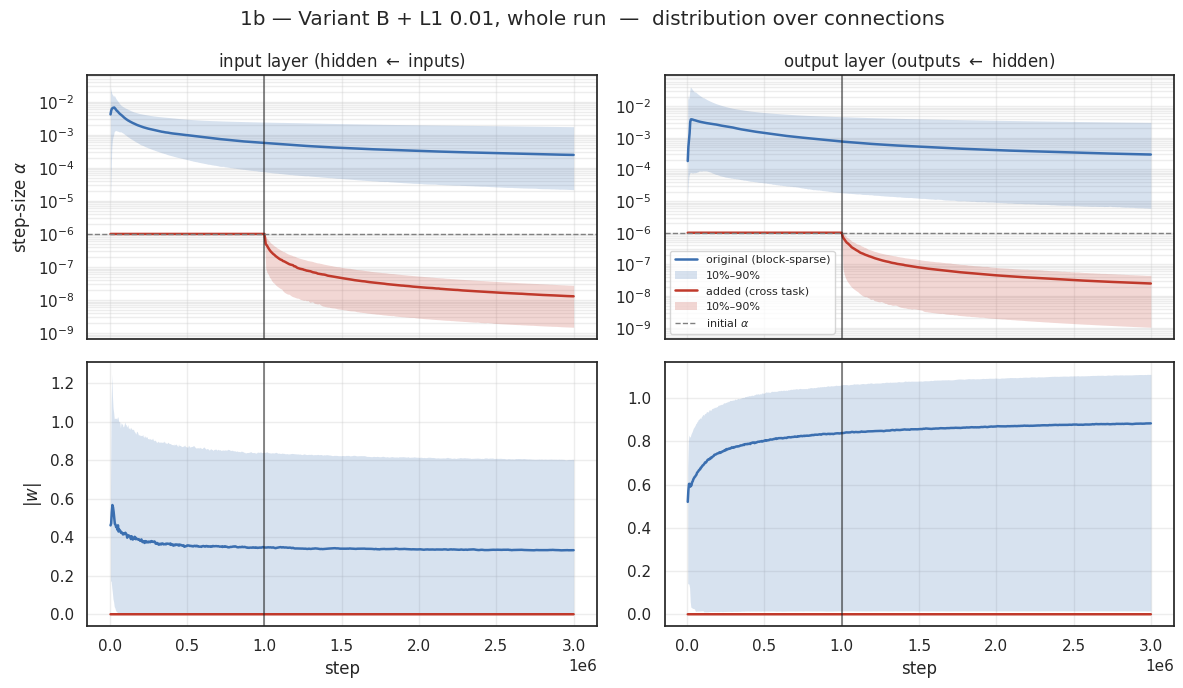

In [27]:
plot_curves(RUNS_1B, '1b — learning curves (line = connections added)', vline=N_PRETRAIN_STEPS)
for label, res in RUNS_1B.items():
    plot_run(res, GROUP_NAMES_1B, f'1b — {label}, after the change',
             from_step=N_PRETRAIN_STEPS, alpha_ref=alpha_ref_for(label))
    plot_run(res, GROUP_NAMES_1B, f'1b — {label}, whole run',
             bands=True, vline=N_PRETRAIN_STEPS, alpha_ref=alpha_ref_for(label))

In [28]:
print(separation_table(RUNS_1B, ('original', 'added'))
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                             run layer  alpha original  alpha added  alpha ratio  |w| original  |w| added  |w| ratio
SGD + momentum (lr 0.002, m 0.9)    w1           0.002        0.002            1         1.329     0.2129      6.246
SGD + momentum (lr 0.002, m 0.9)    w2           0.002        0.002            1          2.81     0.9107      3.086
                       Variant B    w1       0.0001471      3.6e-07        408.7         1.063  0.0006955       1528
                       Variant B    w2        0.002062    1.609e-07    1.282e+04         1.067  0.0009499       1123
             Variant B + L1 0.01    w1       0.0002466    1.298e-08      1.9e+04        0.3328   4.33e-07  7.686e+05
             Variant B + L1 0.01    w2       0.0002965    2.491e-08     1.19e+04        0.8837   1.88e-06  4.701e+05


## Takeaway

* **1a** — a few useless connections escaping is tolerable, the bulk moving is not. Set
  `SHOW_DISTRIBUTIONS = True` for the per-group view rather than the sampled connections.
* **1b** — the cleaner test, since the added connections have a real incentive to move; they should
  stay near 1e-6 with weights near 0.
* A and B are numerically identical while step-sizes are small, so check that the step-sizes left
  1e-6 before comparing the two.
* The static step-size baseline says how much of each result is Autostep's doing. In 1a, not much:
  SGD separates the two groups by |w| about as well as either variant without L1 (8-12x against
  10-14x), and those variants' step-size ratios sit at or below 1 — the weights, not the step-sizes,
  are doing the separating, and Autostep is buying accuracy (MSE 1.18 against 1.26) rather than
  separation. In 1b the two come apart: SGD lets the added connections settle at |w| ~ 0.2 in the
  input layer and ~0.9 in the output layer, while Autostep holds them three orders of magnitude
  below the original connections. Starting a connection at 1e-6 and making it earn its step-size is
  what does that, and a static step-size cannot express it.
* `exp1a_variant_b_numpy.ipynb` is a single-seed, pure-numpy rewrite of just the 1a Variant B
  figure, for reading the mechanism rather than the statistics.